# LIME — a step-by-step walkthrough (breast cancer, real data)

569 real patients, a real 30-feature RandomForest, a real decision
boundary. We build a LIME explanation one layer at a time, then measure
how much of it survives scrutiny — including the parts that do not.

**What you should be able to do afterwards**

1. State what LIME optimizes and name each term of its objective.
2. Follow the mechanism end to end: perturb → predict → weight → fit.
3. Say which parts of a local explanation are trustworthy (direction) and
   which are not (level), and cite the measurement that separates them.
4. Explain why the neighborhood LIME builds is not made of plausible
   patients, and what that costs.

Everything asserted here is measured in this notebook or in its companion,
`lime_internals.ipynb`, which validates each formula against the source
code of the `lime` package.

## Setup

In [1]:
%pip install -q lime scikit-learn matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, roc_auc_score

from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
BLUE = "#315B86"        # benign
TERRACOTTA = "#C96F3F"  # malignant
DARK = "#252525"
GRAY = "#A8A8A8"

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11, "figure.dpi": 140})

## What LIME is

Many models — like the 300-tree RandomForest used here — are black boxes:
they predict well, but you cannot read the "why" off their parameters.
LIME (*Local Interpretable Model-agnostic Explanations*, Ribeiro, Singh &
Guestrin, 2016) does not try to explain the whole model. It explains its
behavior **near one prediction**, by approximating it there with a simple
model — a straight line.

In one sentence: generate synthetic neighbors, ask the real model what it
thinks of each, and fit a weighted regression to those answers, giving
more weight to neighbors closer to the point.

## What we are optimizing

$$\xi(x) = \operatorname*{arg\,min}_{g \,\in\, G} \;\; \mathcal{L}(f, g, \pi_x) \, + \, \Omega(g)$$

| symbol | what it is | here |
|---|---|---|
| $f$ | the real model (black box) | the 300-tree RandomForest |
| $g$ | the local interpretable model | a Ridge regression |
| $\pi_x$ | proximity weight of neighbor $z$ to $x$ | $\pi_x(z) = \sqrt{\exp(-d(x,z)^2/\nu^2)}$ |
| $\mathcal{L}$ | how badly $g$ reproduces $f$ nearby | squared error, weighted by $\pi_x$ |
| $\Omega(g)$ | complexity penalty on $g$ | two things: only 8 of 30 features are kept, and those get an L2 (Ridge, $\alpha=1$) penalty |

One configuration choice worth flagging up front, because it changes what
the output looks like: we pass `discretize_continuous=False`. The package
default is `True`, which bins each feature into quartiles and produces
explanations phrased as intervals ("`worst perimeter` > 120") — the form
you will see in Molnar's book and in most tutorials. Turning it off keeps
the features continuous, which is what lets us draw the explanation as a
line in the plane. Same algorithm, different presentation.

## The model, and how the patient was chosen

**The model.** 300 trees, `min_samples_leaf=3`, not tuned by
cross-validation — a common manual choice (sklearn's default is 100).

**The patient.** Test patient #67. Two things determined the choice, and
it is worth being exact about them, because a vaguer version of this
paragraph was wrong in an earlier draft of this notebook.

1. It sits **near the decision boundary**. This is not cosmetic: the
   distance from the patient to the fit's $P=0.5$ contour equals
   $\lvert g(x)-0.5\rvert / \lVert w\rVert$, so for a confidently
   classified patient that line is *forced* far away and the figure
   degenerates into two unrelated lines.
2. The **plotting axes** are its highest-weight feature
   (`worst perimeter`), plus the highest-ranked feature in its top-8 that
   is not strongly correlated with it (`worst texture`, $r=0.35$). They
   are ranks 1 and 3, **not** the top two: rank 2 is
   `worst concave points`, which correlates with rank 1 at $r=0.81$ and
   would flatten the real patients onto a near 1-D ribbon with no 2-D
   structure to show.

This is a choice made for legibility, not a property of the data. Three
other test patients satisfy the same conditions (`lime_internals.ipynb`
§3); #67 is used because its plottable second axis sits highest in the
ranking. There is nothing unique about it, and the ranking itself shifts
between runs — a limitation of the method rather than a detail of our
setup.

In [3]:
data = load_breast_cancer()
X_all, y_all = data.data, data.target
feature_names = list(data.feature_names)
class_names = list(data.target_names)  # ['malignant', 'benign']
feat_idx = {f: i for i, f in enumerate(feature_names)}

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=RANDOM_STATE, stratify=y_all
)
model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

proba_test = model.predict_proba(X_test)[:, 1]
test_acc = accuracy_score(y_test, model.predict(X_test))
test_auc = roc_auc_score(y_test, proba_test)

instance_idx = 67
row = X_test[instance_idx]
row_proba = proba_test[instance_idx]
predicted = class_names[int(row_proba >= 0.5)]
true_label = class_names[y_test[instance_idx]]

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)
row_scaled = (row - train_mean) / train_std
kernel_width = 0.75 * np.sqrt(len(feature_names))

axis_x_name, axis_y_name = "worst perimeter", "worst texture"
ix, iy = feat_idx[axis_x_name], feat_idx[axis_y_name]

print(f"patient #{instance_idx}: P(benign)={row_proba:.3f}  predicted={predicted}  true={true_label}")
print(f"model: test accuracy={test_acc:.1%}  ROC-AUC={test_auc:.3f}")
print(f"plot axes: {axis_x_name}={row[ix]:.1f} | {axis_y_name}={row[iy]:.1f}  "
      f"(correlation {np.corrcoef(X_train[:, ix], X_train[:, iy])[0, 1]:+.2f})")


def boundary_slice(clf, base_row, grid_x, grid_y):
    """The model's real decision surface, sliced along the plane of the 2
    chosen axes with the other 28 features frozen at THIS patient's values.
    The slice is computed exactly; but note it is itself a set of
    hypothetical patients — freezing 28 correlated measurements while two
    vary produces combinations that do not occur in reality. The same
    objection we will raise against LIME's own sampling applies here."""
    GX, GY = np.meshgrid(grid_x, grid_y)
    points = np.tile(base_row, (GX.size, 1))
    points[:, ix] = GX.ravel()
    points[:, iy] = GY.ravel()
    proba = clf.predict_proba(points)[:, 1]
    return GX, GY, proba.reshape(GX.shape)


# One window for every plot: ±1.5σ around the patient, clipped to the real
# data range. Fixed, so nothing moves between steps except what LIME adds.
WINDOW = 1.5
lo_x, hi_x = X_all[:, ix].min(), X_all[:, ix].max()
lo_y, hi_y = X_all[:, iy].min(), X_all[:, iy].max()
grid_x = np.linspace(max(lo_x, row[ix] - WINDOW * train_std[ix]), min(hi_x, row[ix] + WINDOW * train_std[ix]), 220)
grid_y = np.linspace(max(lo_y, row[iy] - WINDOW * train_std[iy]), min(hi_y, row[iy] + WINDOW * train_std[iy]), 200)
GX, GY, PROB_SLICE = boundary_slice(model, row, grid_x, grid_y)
print(f"P over this window spans {PROB_SLICE.min():.2f}–{PROB_SLICE.max():.2f}; "
      f"crosses 0.5: {PROB_SLICE.min() < 0.5 < PROB_SLICE.max()}")

patient #67: P(benign)=0.581  predicted=benign  true=benign
model: test accuracy=95.1%  ROC-AUC=0.993
plot axes: worst perimeter=113.1 | worst texture=19.1  (correlation +0.35)
P over this window spans 0.42–0.70; crosses 0.5: True


## Drawing tools

Real patients are drawn as **circles** coloured by their *true diagnosis*;
synthetic neighbors as **squares** coloured by the *model's prediction*.
Two different variables, two different shapes — an earlier version of
these figures used the same marker for both and was unreadable.

In [4]:
FIG_DIR = "figures_generated"  # regenerated on each run; committed copies live in ../figures
os.makedirs(FIG_DIR, exist_ok=True)


def new_figure(title, figsize=(8.5, 6.6)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(title, loc="left", fontsize=15, fontweight="bold", pad=12)
    return fig, ax


def draw_base(ax):
    ax.scatter(X_all[y_all == 1, ix], X_all[y_all == 1, iy], s=20, color=BLUE, alpha=0.45,
               linewidth=0, label="real patient · benign")
    ax.scatter(X_all[y_all == 0, ix], X_all[y_all == 0, iy], s=20, color=TERRACOTTA, alpha=0.45,
               linewidth=0, label="real patient · malignant")
    ax.contour(GX, GY, PROB_SLICE, levels=[0.5], colors=[DARK], linewidths=1.8, linestyles="--")
    ax.plot([], [], color=DARK, linewidth=1.8, linestyle="--", label="model boundary (P=0.5)")
    ax.set_xlim(grid_x.min(), grid_x.max())
    ax.set_ylim(grid_y.min(), grid_y.max())
    ax.set_xlabel(axis_x_name, fontsize=11)
    ax.set_ylabel(axis_y_name, fontsize=11)
    ax.tick_params(labelsize=9.5)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)


def draw_patient(ax, annotate=False):
    ax.scatter(row[ix], row[iy], s=220, marker="x", color=DARK, linewidths=3.2,
               zorder=20, label=f"patient #{instance_idx}")
    if annotate:
        ax.annotate(f"P(benign) = {row_proba:.3f}", (row[ix], row[iy]),
                    xytext=(12, 14), textcoords="offset points", fontsize=10,
                    color=DARK, fontweight="bold")


R95 = kernel_width * np.sqrt(-2 * np.log(0.95))   # 1.32σ


def draw_kernel_ring(ax):
    """The kernel's 0.95-weight contour — the only one that fits this window.

    An earlier version of this notebook drew a ±1.2σ ellipse labelled "not
    LIME's kernel": an element defined solely by what it was not. This ring is
    the real thing, and the fact that only the 95% contour fits inside the
    frame is the point. The half-weight contour sits at 4.84σ, measured below."""
    ax.add_patch(Ellipse((row[ix], row[iy]),
                         width=2 * R95 * train_std[ix], height=2 * R95 * train_std[iy],
                         fill=False, color=DARK, linewidth=1.4, linestyle=(0, (4, 4)), alpha=0.85))
    ax.plot([], [], color=DARK, linewidth=1.4, linestyle=(0, (4, 4)), alpha=0.85,
            label="kernel weight = 0.95")


def draw_neighbors(ax, Z, colors=GRAY, sizes=26, alphas=0.6, labels=None):
    """Synthetic neighbors as squares, so they cannot be mistaken for real patients."""
    ax.scatter(Z[:, ix], Z[:, iy], s=sizes, marker="s", color=colors, alpha=alphas,
               linewidth=0.3, edgecolors="white")
    if labels:
        for c, lab in labels:
            ax.scatter([], [], s=40, marker="s", color=c, alpha=0.85,
                       linewidth=0.3, edgecolors="white", label=lab)


def local_isoline(exp, base_row, grid_x, grid_y):
    """The contour of g through the patient: {z : g(z) = g(x)}.

    Deliberately NOT the P=0.5 contour. Both have the same slope, but the
    0.5 contour's *position* is set by the intercept, which this notebook
    measures to be systematically biased (see the fidelity section). The
    contour through g(x) drops the intercept entirely, so it depends only
    on the coefficient ratio — the part that is faithful — and passes
    through the patient by construction."""
    cm = dict(exp.local_exp[1])
    base_scaled = (base_row - train_mean) / train_std
    gx_scaled = (grid_x - train_mean[ix]) / train_std[ix]
    y_scaled = base_scaled[iy] - (cm[ix] / cm[iy]) * (gx_scaled - base_scaled[ix])
    y_line = y_scaled * train_std[iy] + train_mean[iy]
    inside = (y_line >= grid_y.min()) & (y_line <= grid_y.max())
    return y_line, inside


def draw_local_fit(ax, exp):
    cm = dict(exp.local_exp[1])
    if ix not in cm or iy not in cm or abs(cm[iy]) < 1e-9:
        return False
    y_line, inside = local_isoline(exp, row, grid_x, grid_y)
    if inside.any():
        ax.plot(grid_x[inside], y_line[inside], color=DARK, linewidth=3,
                label="local fit (through the patient)")
        return True
    return False


def add_legend(ax, ncol=1):
    ax.legend(loc="upper left", fontsize=8.5, frameon=True, framealpha=0.93,
              edgecolor="none", ncol=ncol)


def save_figure(fig, name):
    fig.savefig(os.path.join(FIG_DIR, f"{name}.png"), dpi=200, bbox_inches="tight")

## Step 1 — the black-box model

A classifier returning P(benign) for any patient. We never look inside;
we only call `predict_proba()`.

**What to look for:** the dashed line is the model's decision boundary in
this slice, and the ✕ sits on it. It is a staircase, not a smooth curve —
a forest splits one feature at a time. Read the boundary's *position* with
caution, though: the cell after the figure refits the forest under a dozen
different seeds and reports how far the boundary wanders. Its exact
placement is a property of this particular fit, not a fact about breast
cancer.

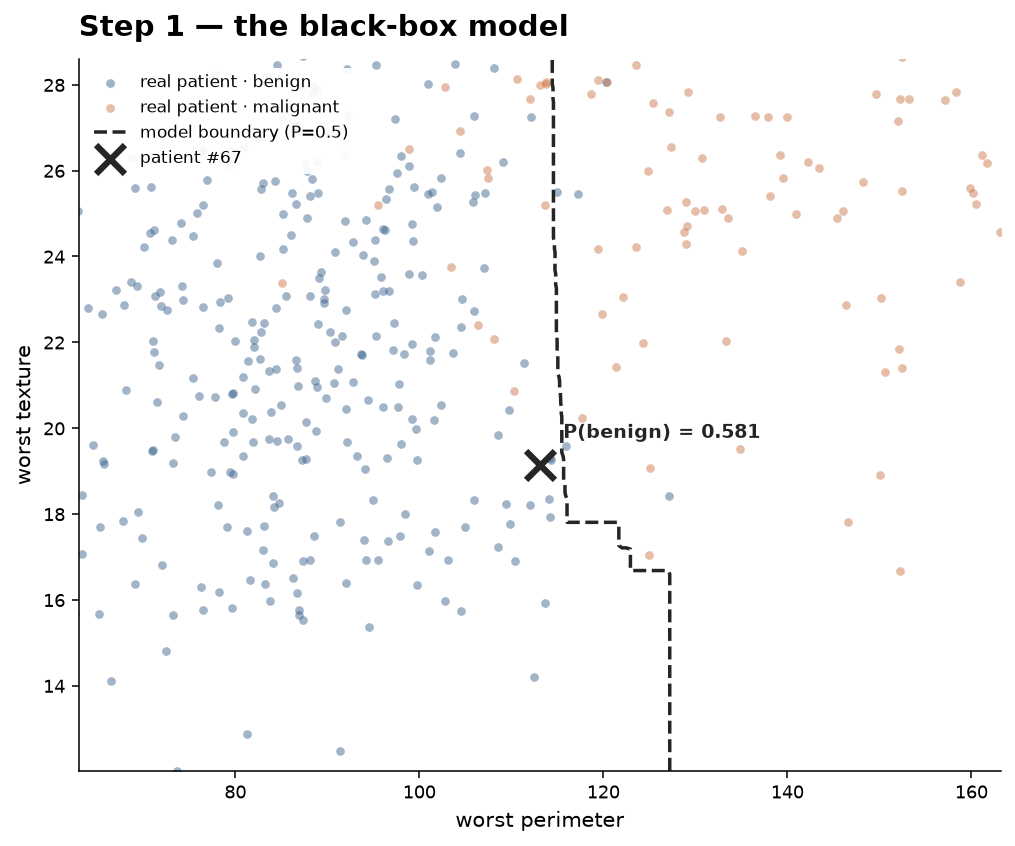

In [5]:
fig, ax = new_figure("Step 1 — the black-box model")
draw_base(ax)
draw_patient(ax, annotate=True)
add_legend(ax)
save_figure(fig, "lime_step_1")
plt.show()

In [6]:
def boundary_distance(clf, base_row):
    """How far the P=0.5 contour passes from the patient, in σ, on this grid."""
    GXs, GYs = np.meshgrid(grid_x, grid_y)
    pts = np.tile(base_row, (GXs.size, 1))
    pts[:, ix] = GXs.ravel()
    pts[:, iy] = GYs.ravel()
    P = clf.predict_proba(pts)[:, 1].reshape(GXs.shape)
    side = P >= 0.5
    if side.all() or (~side).all():
        return np.nan
    edge = np.zeros_like(side)
    edge[:, :-1] |= side[:, :-1] != side[:, 1:]
    edge[:-1, :] |= side[:-1, :] != side[1:, :]
    return float(np.min(np.hypot((GXs[edge] - base_row[ix]) / train_std[ix],
                                 (GYs[edge] - base_row[iy]) / train_std[iy])))


seed_dists = []
for s in range(12):
    alt = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=s)
    alt.fit(X_train, y_train)
    seed_dists.append(boundary_distance(alt, row))
seed_dists = np.array([d for d in seed_dists if d == d])
print(f"distance from the patient to the boundary, across {len(seed_dists)} forest seeds:")
print(f"  min {seed_dists.min():.3f}σ   median {np.median(seed_dists):.3f}σ   max {seed_dists.max():.3f}σ")
print(f"  (this notebook's seed 42: {boundary_distance(model, row):.3f}σ)")
print("→ the staircase is real, but where exactly it falls is seed-dependent.")

distance from the patient to the boundary, across 12 forest seeds:
  min 0.062σ   median 0.291σ   max 0.481σ
  (this notebook's seed 42: 0.076σ)
→ the staircase is real, but where exactly it falls is seed-dependent.


## Step 2 — the local neighborhood

LIME needs a notion of "near". Each feature has its own scale, so each
gets its own width (its σ in the training set).

**What to look for.** The dashed ring is LIME's own kernel, drawn at the
0.95-weight contour — and that is the only contour of it that fits inside
this frame. The cell below measures where the others fall: the half-weight
contour is at 4.84σ, more than three times the width of this window, and it
encloses a large fraction of the entire dataset. The kernel localizes far
less than its name suggests, and that will matter twice before the notebook
ends. (Because both axes are scaled by their own σ, the ring renders round
regardless of the feature scales — do not read shape into it.)

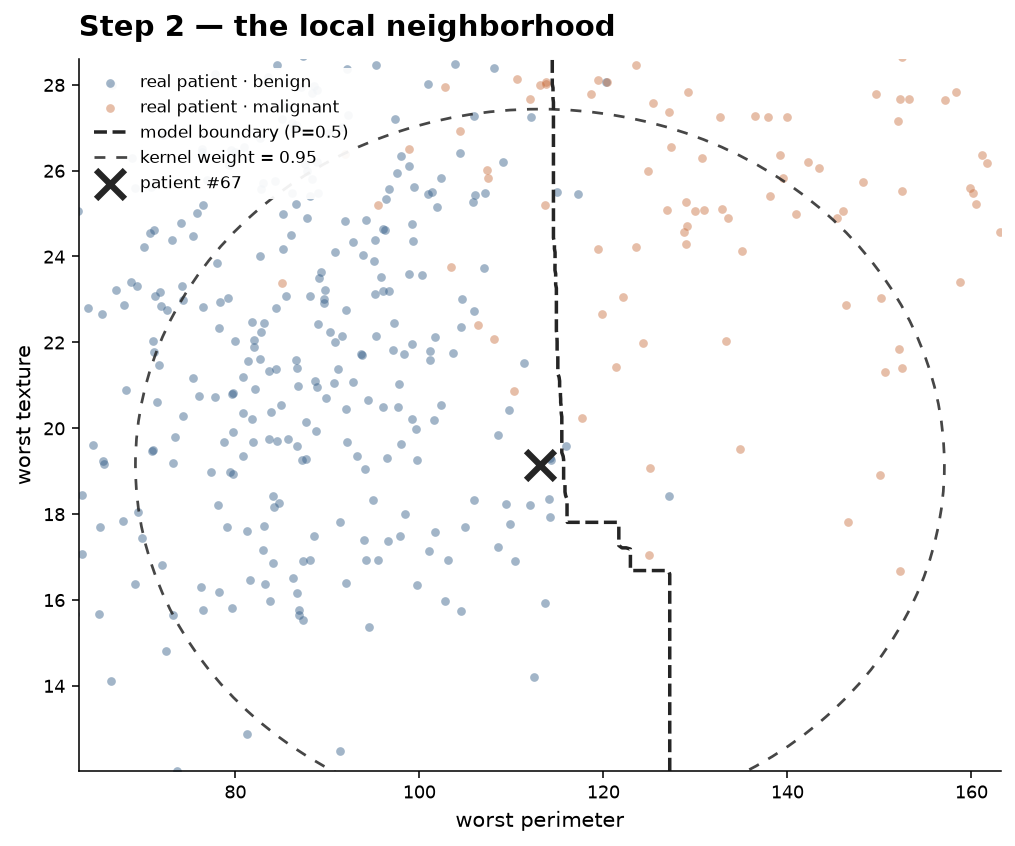

In [7]:
fig, ax = new_figure("Step 2 — the local neighborhood")
draw_base(ax)
draw_kernel_ring(ax)
draw_patient(ax)
add_legend(ax)
save_figure(fig, "lime_step_2")
plt.show()

In [8]:
# How big is LIME's neighborhood really? Measured, not asserted.
w_real_all = np.sqrt(np.exp(-(np.linalg.norm((X_all - train_mean) / train_std
                                             - row_scaled, axis=1) ** 2) / kernel_width ** 2))
for wt in (0.95, 0.90, 0.75, 0.50):
    r = kernel_width * np.sqrt(-2 * np.log(wt))
    print(f"  kernel weight {wt:.2f} -> radius {r:5.2f}σ   "
          f"{'fits' if r < WINDOW else 'outside'} the ±{WINDOW}σ window")
print(f"\nreal patients carrying kernel weight > 0.5: "
      f"{(w_real_all > 0.5).sum()} of {len(w_real_all)} ({(w_real_all > 0.5).mean():.0%})")
print("→ the 'local' neighborhood contains a large share of the whole study.")

  kernel weight 0.95 -> radius  1.32σ   fits the ±1.5σ window
  kernel weight 0.90 -> radius  1.89σ   outside the ±1.5σ window
  kernel weight 0.75 -> radius  3.12σ   outside the ±1.5σ window
  kernel weight 0.50 -> radius  4.84σ   outside the ±1.5σ window

real patients carrying kernel weight > 0.5: 239 of 569 (42%)
→ the 'local' neighborhood contains a large share of the whole study.


## Step 3 — perturbation, and what is wrong with it

$$z = \mu + \sigma \cdot \mathcal{N}(0,1)$$

across all 30 features at once, each with its own training mean and σ.
Note what this says: the cloud is centred on the **dataset**, not on the
patient (`sample_around_instance=False` is the package default). Every
patient in this dataset gets essentially the same cloud; only the weights
in step 5 differ.

**The caveat that matters most in this notebook.** Sampling each feature
independently destroys the correlations that make a patient physically
possible. The cell below measures the damage. It is not a rounding error:
a large majority of the synthetic "patients" have at least one negative
measurement — negative radius, negative area — and the ratio between
`worst perimeter` and `worst radius`, which is $\approx 2\pi$ for any real
closed shape, ranges over more than an order of magnitude.

This is not a footnote about LIME. It is the mechanism behind the result
in the fidelity section below.

In [9]:
rng_vis = np.random.RandomState(RANDOM_STATE)
N_VIS = 500
Z_vis = train_mean + train_std * rng_vis.normal(0, 1, size=(N_VIS, len(feature_names)))

# how impossible is this cloud, really?
rng_big = np.random.RandomState(RANDOM_STATE + 1)
Z_big = train_mean + train_std * rng_big.normal(0, 1, size=(5000, len(feature_names)))
frac_negative = (Z_big < 0).any(axis=1).mean()
ratio_syn = Z_big[:, feat_idx["worst perimeter"]] / Z_big[:, feat_idx["worst radius"]]
ratio_real = X_all[:, feat_idx["worst perimeter"]] / X_all[:, feat_idx["worst radius"]]
in_window = ((Z_vis[:, ix] >= grid_x.min()) & (Z_vis[:, ix] <= grid_x.max()) &
             (Z_vis[:, iy] >= grid_y.min()) & (Z_vis[:, iy] <= grid_y.max()))

print(f"synthetic patients with at least one NEGATIVE measurement: {frac_negative:.0%}")
print(f"worst perimeter / worst radius  —  real data: "
      f"[{ratio_real.min():.2f}, {ratio_real.max():.2f}]   (2π = {2*np.pi:.2f})")
print(f"worst perimeter / worst radius  —  synthetic (1–99 pct): "
      f"[{np.percentile(ratio_syn, 1):.2f}, {np.percentile(ratio_syn, 99):.2f}]")
print(f"\n{in_window.sum()} of the {N_VIS} plotted neighbors fall inside this window "
      f"({in_window.mean():.0%}); the rest are outside the frame.")

synthetic patients with at least one NEGATIVE measurement: 76%
worst perimeter / worst radius  —  real data: [6.22, 7.67]   (2π = 6.28)
worst perimeter / worst radius  —  synthetic (1–99 pct): [1.82, 21.50]

275 of the 500 plotted neighbors fall inside this window (55%); the rest are outside the frame.


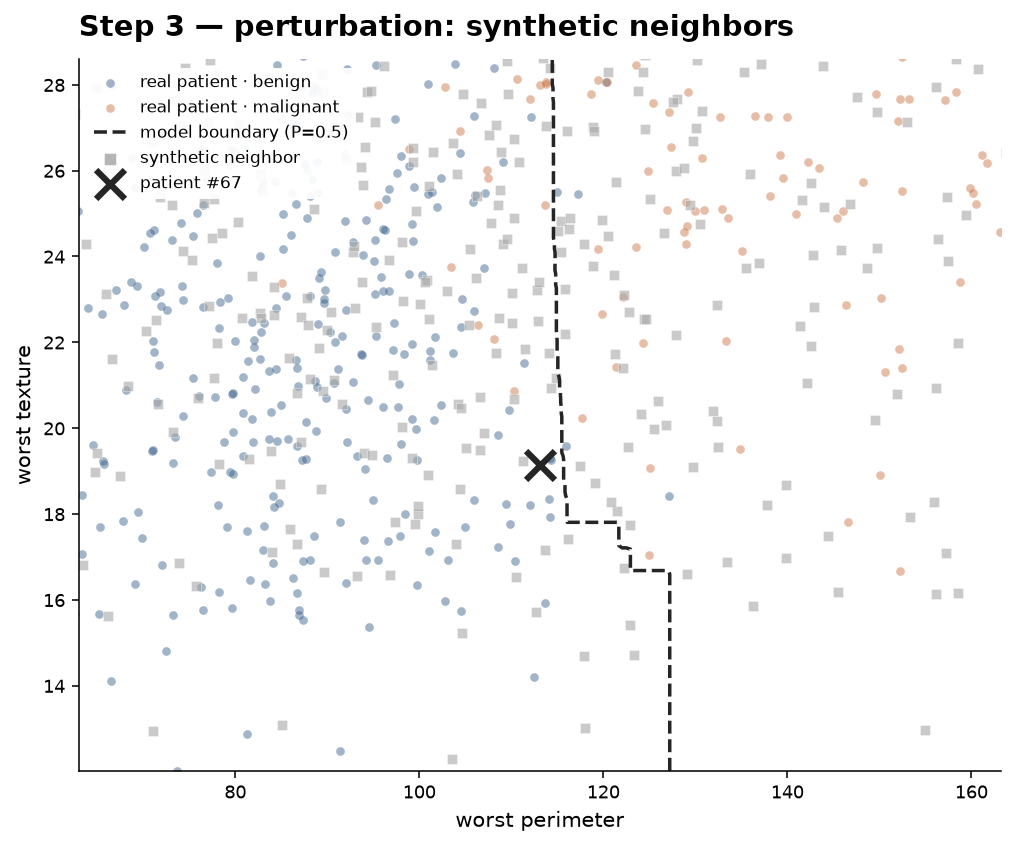

In [10]:
fig, ax = new_figure("Step 3 — perturbation: synthetic neighbors")
draw_base(ax)
draw_neighbors(ax, Z_vis, colors=GRAY, labels=[(GRAY, "synthetic neighbor")])
draw_patient(ax)
add_legend(ax)
save_figure(fig, "lime_step_3")
plt.show()

## Step 4 — what the model says about each neighbor

The only moment the real model is queried: `predict_proba` on every
synthetic neighbor.

**What to look for — and it is not what you might expect.** The squares
do *not* separate cleanly along the dashed boundary. They cannot: each
square has random values on the other 28 features, while the dashed
contour was computed holding those 28 fixed at *this patient's* values.
The cell prints how weak the agreement is. This is the picture of why a
2-D slice cannot determine a 30-D prediction — worth dwelling on before
anyone over-reads the geometry in the next steps.

in-frame neighbors whose prediction matches the side of the drawn contour: 68%
(majority-class baseline: 53% — so the contour explains little about them)


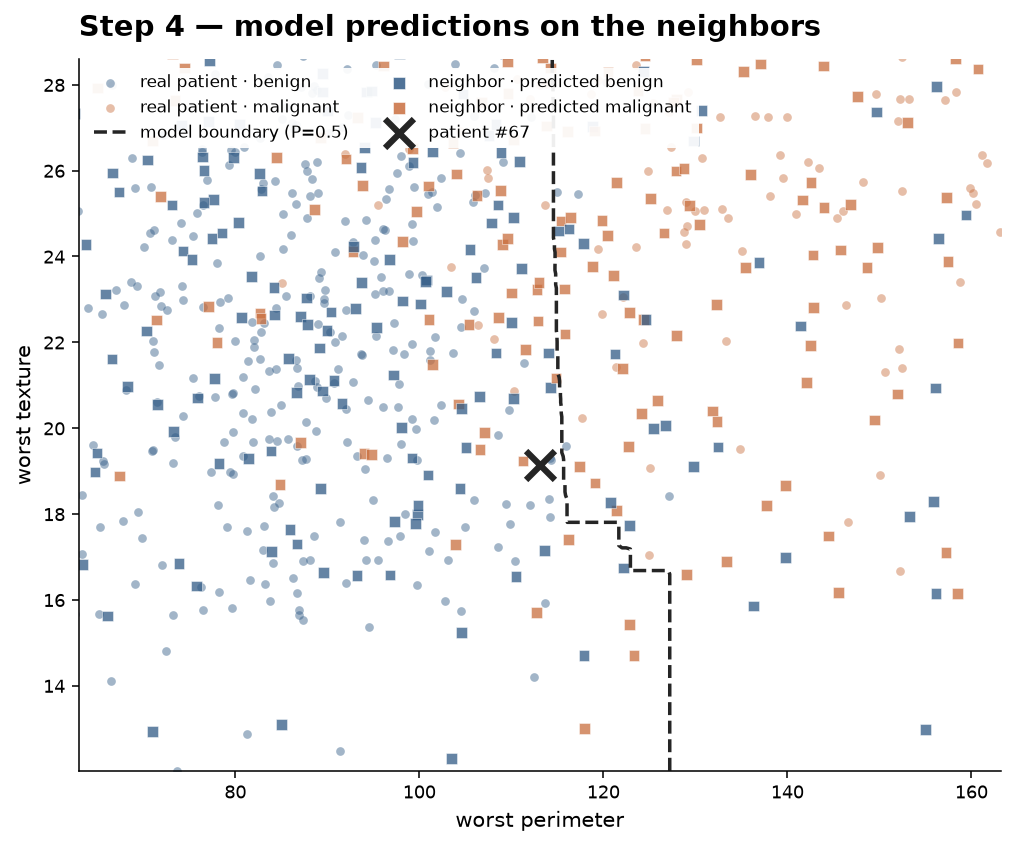

In [11]:
Z_vis_proba = model.predict_proba(Z_vis)[:, 1]
neighbor_colors = np.where(Z_vis_proba >= 0.5, BLUE, TERRACOTTA)

# do the neighbors agree with the side of the drawn contour they land on?
gi = np.clip(np.searchsorted(grid_x, Z_vis[in_window, ix]) - 1, 0, len(grid_x) - 2)
gj = np.clip(np.searchsorted(grid_y, Z_vis[in_window, iy]) - 1, 0, len(grid_y) - 2)
side_of_contour = PROB_SLICE[gj, gi] >= 0.5
agree = (side_of_contour == (Z_vis_proba[in_window] >= 0.5)).mean()
baseline = max((Z_vis_proba[in_window] >= 0.5).mean(), 1 - (Z_vis_proba[in_window] >= 0.5).mean())
print(f"in-frame neighbors whose prediction matches the side of the drawn contour: {agree:.0%}")
print(f"(majority-class baseline: {baseline:.0%} — so the contour explains little about them)")

fig, ax = new_figure("Step 4 — model predictions on the neighbors")
draw_base(ax)
draw_neighbors(ax, Z_vis, colors=neighbor_colors, sizes=30, alphas=0.75,
               labels=[(BLUE, "neighbor · predicted benign"),
                       (TERRACOTTA, "neighbor · predicted malignant")])
draw_patient(ax)
add_legend(ax, ncol=2)
save_figure(fig, "lime_step_4")
plt.show()

## Step 5 — proximity weighting

$$\pi_x(z) = \sqrt{\exp\!\left(-\dfrac{d(x,z)^2}{\nu^2}\right)}, \qquad \nu = 0.75\sqrt{30}$$

**What to look for:** square size and opacity now encode $\pi_x$ — the
first step where neighbors stop being equals. The distance is computed
over all **30 standardized** features, not the two on screen, so a square
that looks far from the ✕ can still be heavy if it resembles the patient
elsewhere. Sizes are faithful to the weights, not to on-screen distance.

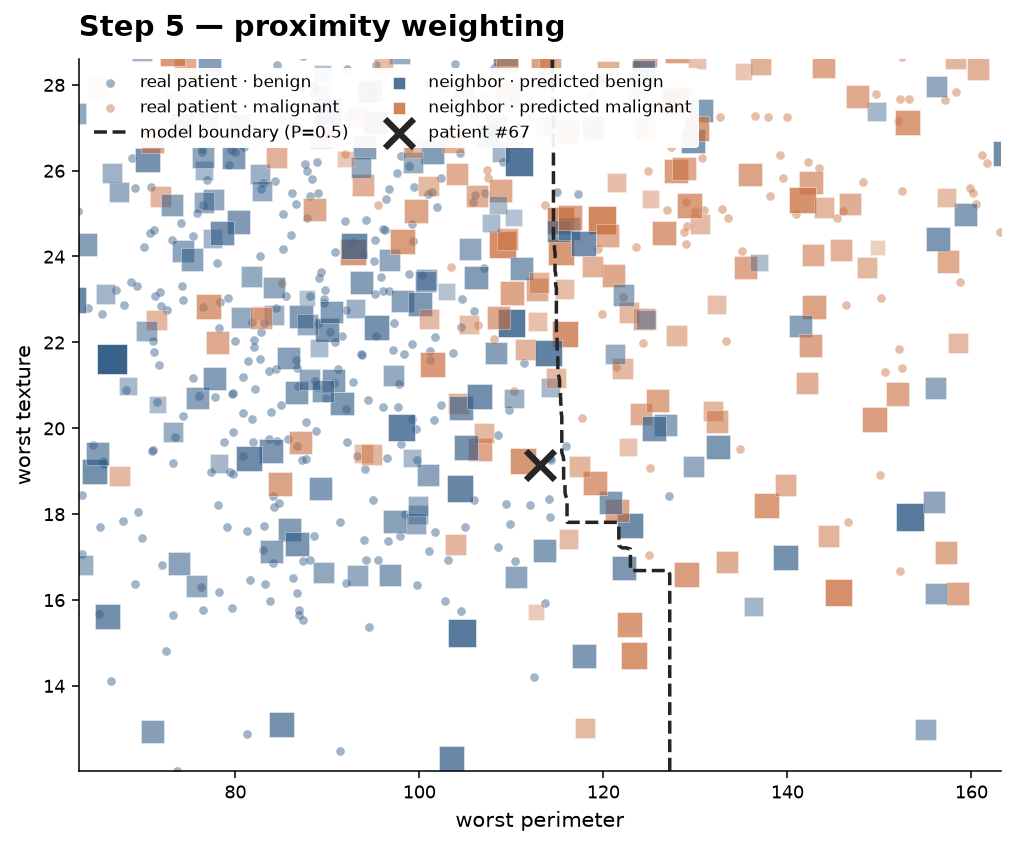

In [12]:
Z_vis_scaled = (Z_vis - train_mean) / train_std
dist_vis = np.linalg.norm(Z_vis_scaled - row_scaled, axis=1)
weight_vis = np.sqrt(np.exp(-(dist_vis ** 2) / (kernel_width ** 2)))
neighbor_sizes = 18 + 230 * (weight_vis / weight_vis.max())
neighbor_alphas = np.clip(0.18 + 0.78 * (weight_vis / weight_vis.max()), 0, 1)

fig, ax = new_figure("Step 5 — proximity weighting")
draw_base(ax)
draw_neighbors(ax, Z_vis, colors=neighbor_colors, sizes=neighbor_sizes, alphas=neighbor_alphas,
               labels=[(BLUE, "neighbor · predicted benign"),
                       (TERRACOTTA, "neighbor · predicted malignant")])
draw_patient(ax)
add_legend(ax, ncol=2)
save_figure(fig, "lime_step_5")
plt.show()

## Step 6 — the local fit

A Ridge regression ($\alpha=1$) on the 8 selected features, each neighbor
weighted by its $\pi_x$. What is drawn is the contour of that fit **through
the patient**.

That is a deliberate choice, and the reason is measured two cells below.
A linear fit gives you two things: a *direction* (the coefficient ratio)
and a *level* (the intercept). Here the direction is excellent and the
level is systematically wrong, so the figure shows the direction and
refuses to show the level. Drawing the fit's $P=0.5$ contour instead —
the conventional choice — would place this patient on the malignant side
of that same explanation.

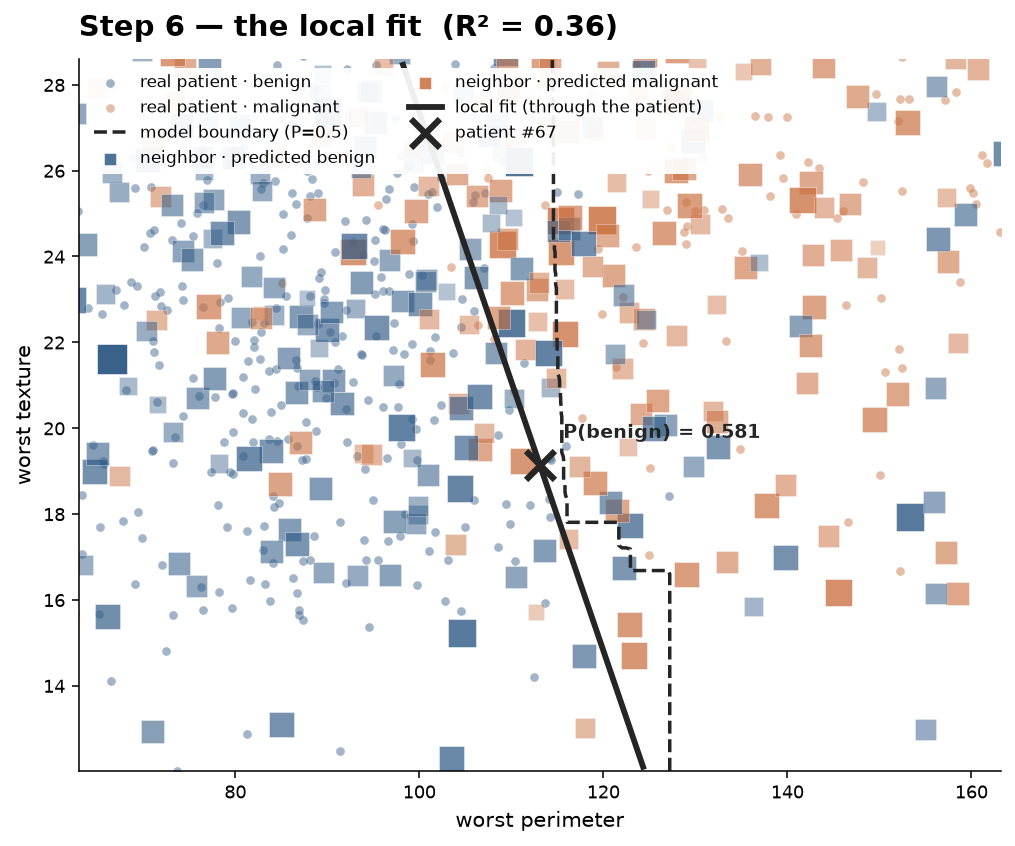

In [13]:
explainer = LimeTabularExplainer(
    X_train, feature_names=feature_names, class_names=class_names,
    discretize_continuous=False, random_state=RANDOM_STATE,
)
exp = explainer.explain_instance(
    row, model.predict_proba, num_features=8, num_samples=5000, labels=(1,)
)
r2 = exp.score
weights_map = {feature_names[f]: w for f, w in exp.local_exp[1]}
top_feat = max(weights_map, key=lambda f: abs(weights_map[f]))
i_top = feat_idx[top_feat]

fig, ax = new_figure(f"Step 6 — the local fit  (R² = {r2:.2f})")
draw_base(ax)
draw_neighbors(ax, Z_vis, colors=neighbor_colors, sizes=neighbor_sizes, alphas=neighbor_alphas,
               labels=[(BLUE, "neighbor · predicted benign"),
                       (TERRACOTTA, "neighbor · predicted malignant")])
fit_drawn = draw_local_fit(ax, exp)
draw_patient(ax, annotate=True)
add_legend(ax, ncol=2)
save_figure(fig, "lime_step_6")
plt.show()

### Is the direction right? Measure it.

The claim "the straight line approximates the boundary locally" is
testable: compare the direction of the fit's gradient to the direction in
which the real model's probability actually changes around the patient
(finite differences, ±0.3σ).

In [14]:
def numeric_gradient(h=0.3):
    g = np.zeros(len(feature_names))
    for j in range(len(feature_names)):
        a, b = row.copy(), row.copy()
        a[j] += h * train_std[j]
        b[j] -= h * train_std[j]
        g[j] = (model.predict_proba(a.reshape(1, -1))[0, 1]
                - model.predict_proba(b.reshape(1, -1))[0, 1]) / (2 * h)
    return g


grad_f = numeric_gradient()
cm = dict(exp.local_exp[1])
grad_g = np.zeros(len(feature_names))
for j, w in cm.items():
    grad_g[j] = w


def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))


ang_g = np.degrees(np.arctan2(grad_g[iy], grad_g[ix]))
ang_f = np.degrees(np.arctan2(grad_f[iy], grad_f[ix]))
print(f"direction of the fit, in the plotted plane:      {ang_g:+.1f}°")
print(f"direction the model actually changes (measured): {ang_f:+.1f}°")
print(f"disagreement: {abs(ang_g - ang_f):.1f}°   —   cosine similarity {cosine(grad_g[[ix, iy]], grad_f[[ix, iy]]):+.3f}")
print(f"\nbut across all 30 features, cosine(grad g, grad f) = {cosine(grad_g, grad_f):+.3f}")
print("→ in the plane we plot, the fit points almost exactly where the model does.")
print("  Across all 30 features it is only moderately aligned — so the ranking of")
print("  the smaller coefficients deserves far less confidence than the leading one.")

direction of the fit, in the plotted plane:      -163.3°
direction the model actually changes (measured): -167.4°
disagreement: 4.1°   —   cosine similarity +0.997

but across all 30 features, cosine(grad g, grad f) = +0.565
→ in the plane we plot, the fit points almost exactly where the model does.
  Across all 30 features it is only moderately aligned — so the ranking of
  the smaller coefficients deserves far less confidence than the leading one.


### Is the level right? Measure that too.

Same fit, different question: does $g$ reproduce the model's *value* at
the patient?

In [15]:
print(f"f(x), the real model:  {row_proba:.4f}   → {class_names[int(row_proba >= 0.5)]}")
print(f"g(x), the linear fit:  {exp.local_pred[0]:.4f}   → {class_names[int(exp.local_pred[0] >= 0.5)]}")
print(f"gap: {abs(row_proba - exp.local_pred[0]):.4f}")
print("\nacross 8 re-runs of LIME on this same patient:")
gxs = []
for s in range(8):
    e = LimeTabularExplainer(
        X_train, feature_names=feature_names, class_names=class_names,
        discretize_continuous=False, random_state=RANDOM_STATE + s,
    ).explain_instance(row, model.predict_proba, num_features=8, num_samples=5000, labels=(1,))
    gxs.append(e.local_pred[0])
gxs = np.array(gxs)
print(f"  g(x) = {gxs.mean():.4f} ± {gxs.std():.4f}   (f(x) = {row_proba:.4f})")
print(f"  lands on the correct side of 0.5 in {int((gxs >= 0.5).sum())}/8 runs")
print("\n→ the bias is stable, not noisy: g(x) reliably lands near 0.50 while the model")
print("  says 0.58. The next cell shows where that 0.50 comes from.")

f(x), the real model:  0.5812   → benign
g(x), the linear fit:  0.4968   → malignant
gap: 0.0843

across 8 re-runs of LIME on this same patient:


  g(x) = 0.4988 ± 0.0025   (f(x) = 0.5812)
  lands on the correct side of 0.5 in 3/8 runs

→ the bias is stable, not noisy: g(x) reliably lands near 0.50 while the model
  says 0.58. The next cell shows where that 0.50 comes from.


### Why the level is biased — and a surprise about the kernel

The usual explanation would be "the fit is local, so it is pulled toward
nearby points". Test it directly: refit the same Ridge with the kernel
weights **removed entirely** and see what changes.

In [16]:
Z_probe_s = (Z_big - train_mean) / train_std
f_big = model.predict_proba(Z_big)[:, 1]
d_big = np.linalg.norm(Z_probe_s - row_scaled, axis=1)
w_big = np.sqrt(np.exp(-(d_big ** 2) / kernel_width ** 2))


def lime_pipeline(base_scaled, sample_weight):
    """Both of the package's stages, not a shortcut: the weighted
    `highest_weights` selection (auxiliary Ridge, alpha=0.01) and then
    Ridge(alpha=1) on the 8 survivors. Running the real pipeline matters,
    because the selection is itself weighted — deleting the kernel could in
    principle change *which* features are chosen, and a single 30-feature
    fit would hide that."""
    aux = Ridge(alpha=0.01).fit(Z_probe_s, f_big, sample_weight=sample_weight)
    top8 = np.argsort(-np.abs(aux.coef_ * base_scaled))[:8]
    fit = Ridge(alpha=1.0).fit(Z_probe_s[:, top8], f_big, sample_weight=sample_weight)
    return fit.intercept_ + fit.coef_ @ base_scaled[top8], set(top8)


g_kernel, feats_kernel = lime_pipeline(row_scaled, w_big)
g_uniform, feats_uniform = lime_pipeline(row_scaled, np.ones(len(f_big)))

print(f"mean of f over the whole cloud:        {f_big.mean():.4f}")
print(f"g(x) with LIME's proximity kernel:     {g_kernel:.4f}")
print(f"g(x) with NO kernel at all (uniform):  {g_uniform:.4f}")
print(f"features the two runs agree on:        {len(feats_kernel & feats_uniform)}/8")
print(f"\nf(x), for reference: {row_proba:.4f}")

mean of f over the whole cloud:        0.4818
g(x) with LIME's proximity kernel:     0.5000
g(x) with NO kernel at all (uniform):  0.4991
features the two runs agree on:        8/8

f(x), for reference: 0.5812


Two things follow, and the second is uncomfortable.

**The level.** The cloud's mean prediction is ≈0.48. A linear fit that
explains only a third of the variance necessarily shrinks its predictions
toward that mean — that is what a poor $R^2$ *means*. So $g(x)$ lands near
0.5 for almost any patient: it is regression to the cloud's mean, not a
statement about the patient. Nothing is broken; the intercept simply carries
information about the cloud rather than about the patient, which is exactly
why the figure refuses to draw the $P=0.5$ contour.

**The kernel.** Deleting it changes essentially nothing — same $g(x)$ to
three decimals, and the selection stage picks the very same 8 features. On this
dataset, with the default width $\nu = 0.75\sqrt{30}$, LIME's proximity
weighting is close to inert, and what we have been calling a *local* fit is
very nearly a global linear approximation of $f$ over the cloud. (Verified
across six patients in `lime_internals.ipynb` §11, not just this one.)

This is worth sitting with, because the "L" in LIME is doing less work here
than the name promises. The direction still turns out to be informative —
a global linear fit can recover the right gradient when $f$ is smooth
enough in the relevant directions — but it is informative for a reason
other than locality, and no one should claim otherwise on this evidence.

### What LIME actually hands you

The line is a teaching device. What the library returns, and what
practitioners read, is the coefficient list — the direction, decomposed
feature by feature.

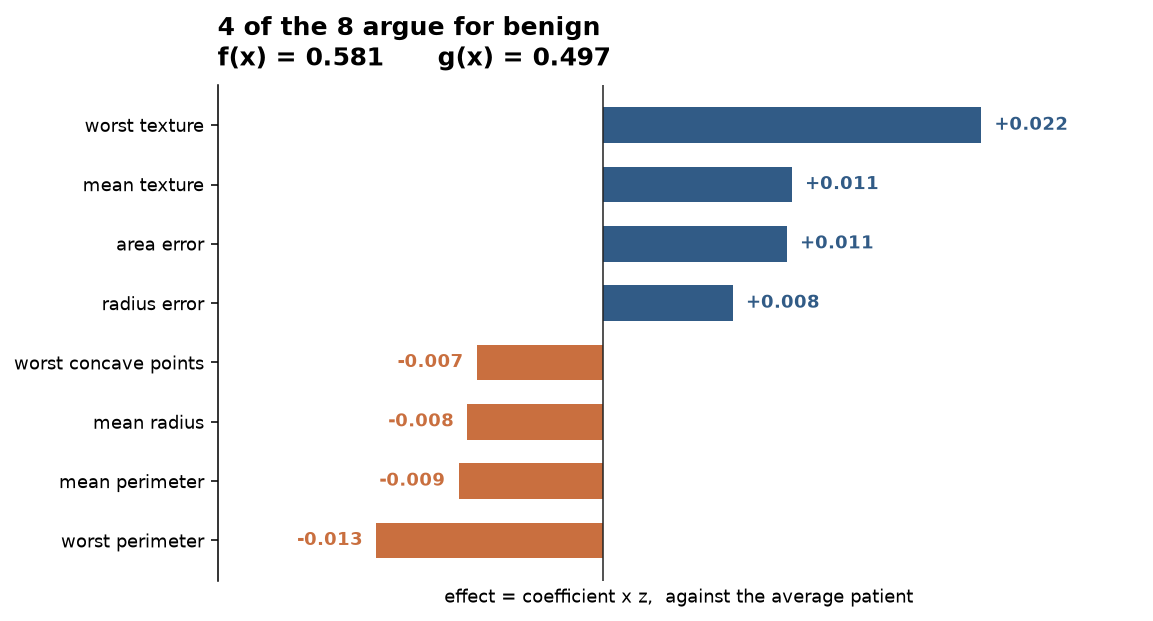

coefficients below zero : 4 of 8
values below the mean: 4 of 8 -> there a negative slope argues for BENIGN

A slope is not a contribution. A contribution needs a declared reference:
    g(x) - g(r) = sum_j c_j (x_j - r_j)
    r = training mean (r = 0)    sum = -0.0578   terms below zero: 8/8
    r = training median          sum = -0.0589   terms below zero: 8/8
    r = mean benign patient      sum = -0.0606   terms below zero: 8/8
    r = mean malignant patient   sum = -0.0530   terms below zero: 4/8

So the honest reading is the fit itself, which needs no reference:
    g(x) = 0.4968   f(x) = 0.5812   gap 0.0843
    and they land on opposite sides of 0.5: True


In [17]:
# Plot the EFFECT, coefficient x this patient's standardized value, measured
# against the average patient. That is the object Molnar's chapter plots ("the
# weight times the actual feature value") and the object lime's own selection
# step ranks by (lime_base.py:206). Not the bare coefficient: all eight of those
# are negative here, and an earlier version of this cell said so and concluded
# the patient looks malignant. Four of the eight values sit BELOW the mean, so
# four of those negative slopes argue for benign. In standardized units the
# reference is the average patient and intercept + sum = g(x) exactly; in raw
# units the reference would be a tumour measuring zero on everything.
eff = {f: weights_map[f] * row_scaled[feature_names.index(f)] for f in weights_map}
order = sorted(eff, key=lambda f: eff[f])
vals = [eff[f] for f in order]

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.barh(order, vals, height=0.60,
        color=[TERRACOTTA if v < 0 else BLUE for v in vals])
span = max(abs(v) for v in vals)
for k, v in enumerate(vals):
    ax.text(v + (0.035 * span if v > 0 else -0.035 * span), k, f"{v:+.3f}",
            va="center", ha="left" if v > 0 else "right", fontsize=9,
            fontweight="bold", color=BLUE if v > 0 else TERRACOTTA)
ax.axvline(0, color=DARK, linewidth=0.8)
ax.set_xlim(min(vals) - 0.42 * span, max(vals) + 0.42 * span)
ax.set_xticks([])
n_neg = sum(v < 0 for v in vals)
ax.set_title(f"{len(vals) - n_neg} of the {len(vals)} argue for benign\n"
             f"f(x) = {row_proba:.3f}      g(x) = {exp.local_pred[0]:.3f}",
             loc="left", fontsize=13, fontweight="bold", pad=10)
ax.set_xlabel("effect = coefficient x z,  against the average patient", fontsize=9.5)
ax.tick_params(axis="y", labelsize=9)
for s in ["top", "right", "bottom"]:
    ax.spines[s].set_visible(False)
save_figure(fig, "lime_step_6b_coefficients")
plt.show()

z8 = np.array([row_scaled[feature_names.index(f)] for f in order])
c8 = np.array(vals)
print(f"coefficients below zero : {int((c8 < 0).sum())} of 8")
print(f"values below the mean: {int((z8 < 0).sum())} of 8 "
      f"-> there a negative slope argues for BENIGN")
print()
print("A slope is not a contribution. A contribution needs a declared reference:")
print("    g(x) - g(r) = sum_j c_j (x_j - r_j)")
for label, ref in [("training mean (r = 0)", np.zeros(len(feature_names))),
                   ("training median", (np.median(X_train, axis=0) - train_mean) / train_std),
                   ("mean benign patient", (X_train[y_train == 1].mean(axis=0) - train_mean) / train_std),
                   ("mean malignant patient", (X_train[y_train == 0].mean(axis=0) - train_mean) / train_std)]:
    r8 = np.array([ref[feature_names.index(f)] for f in order])
    t = c8 * (z8 - r8)
    print(f"    r = {label:24s} sum = {t.sum():+.4f}   terms below zero: {int((t < 0).sum())}/8")
print()
print("So the honest reading is the fit itself, which needs no reference:")
print(f"    g(x) = {exp.local_pred[0]:.4f}   f(x) = {row_proba:.4f}   "
      f"gap {abs(row_proba - exp.local_pred[0]):.4f}")
print(f"    and they land on opposite sides of 0.5: "
      f"{(exp.local_pred[0] < 0.5) != (row_proba < 0.5)}")


## Fidelity: what R² does and does not mean

$R^2$ measures how well $g$ tracks $f$ across the weighted neighborhood.
It is tempting to read it as an explanation-quality score, prefer high
values, and distrust low ones. That reading does not survive measurement.

Across all 143 test patients, $R^2$ correlates with how *confident* the
prediction was — Spearman $\rho = +0.61$, $p \approx 4\times10^{-16}$
(computed in `lime_internals.ipynb` §9): mean $R^2$ of 0.47 for borderline
patients versus 0.61 for confident ones.

**The obvious explanation for this is wrong, and it is worth seeing why.**
One would guess: far from the boundary the model is saturated, its output
barely moves, and a straight line reproduces "almost constant" easily. Two
measurements kill that story:

In [18]:
Z_probe = Z_big
f_probe = model.predict_proba(Z_probe)[:, 1]
f_test = model.predict_proba(X_test)[:, 1]  # held-out only: the training rows are memorized
sat_probe = (f_probe < 0.05) | (f_probe > 0.95)
sat_test = (f_test < 0.05) | (f_test > 0.95)
print(f"f on LIME's synthetic cloud: range [{f_probe.min():.2f}, {f_probe.max():.2f}]; "
      f"saturated (<0.05 or >0.95) in {sat_probe.sum()} of {len(f_probe)} draws "
      f"({sat_probe.mean():.2%})")
print(f"f on held-out real patients: saturated in {sat_test.sum()} of {len(f_test)} "
      f"({sat_test.mean():.1%})")

conf_all, wvar_all = [], []
for i in range(len(X_test)):
    dd = np.linalg.norm((Z_probe - train_mean) / train_std - (X_test[i] - train_mean) / train_std, axis=1)
    ww = np.sqrt(np.exp(-(dd ** 2) / kernel_width ** 2))
    mbar = np.average(f_probe, weights=ww)
    wvar_all.append(np.average((f_probe - mbar) ** 2, weights=ww))
    conf_all.append(abs(proba_test[i] - 0.5))
conf_all, wvar_all = np.array(conf_all), np.array(wvar_all)
b, c = conf_all < 0.15, conf_all > 0.30
print(f"\nweighted variance of f over the neighborhood:")
print(f"  borderline patients: {wvar_all[b].mean():.4f}")
print(f"  confident patients:  {wvar_all[c].mean():.4f}")

f on LIME's synthetic cloud: range [0.07, 0.97]; saturated (<0.05 or >0.95) in 2 of 5000 draws (0.04%)
f on held-out real patients: saturated in 101 of 143 (70.6%)

weighted variance of f over the neighborhood:
  borderline patients: 0.0228
  confident patients:  0.0227


The model **essentially never saturates anywhere LIME looks**: 2 draws out
of 5,000 leave the middling band, while on held-out real patients about
seven in ten predictions are saturated. LIME does not visit that region —
because, as step 3 measured, the cloud is not made of possible patients.
And the weighted variance of $f$ is the same for borderline and confident
patients, because they share the same cloud.

There is also an algebraic problem with the saturation story: since
$R^2 = 1 - \mathrm{SSE}/\mathrm{SST}$, a near-constant target *shrinks*
SST and makes a high $R^2$ harder to reach, not easier. The story predicts
the opposite of the observed correlation.

**So what does explain it?** Confident patients do sit further from the
training centroid (about 4.8σ versus 2.7σ). The natural next step — that
this makes the kernel concentrate weight on fewer points, so the fit has
less to reconcile — is also not supported: the weight skew barely differs
between the groups, and the effective sample size stays at roughly 93% of
the nominal one, so the weights are close to uniform for everybody
(`lime_internals.ipynb` §7, §9).

**And then the finding itself did not survive.** With both mechanisms
falsified, the remaining question was whether the correlation is a fact
about LIME or a fact about this particular setting. Re-measured under one
common protocol (55 test points, 2,000 perturbations each), it reads
$\rho = +0.70$ here, weakens to $+0.27$ and $+0.17$ (n.s.) when the model
is swapped for a gradient boosting machine and a logistic regression, and
vanishes at $-0.07$ (n.s.) on an unrelated dataset — wine, thirteen
chemical measurements with nothing to do with cancer. The replication is in
`lime_internals.ipynb` §9b.

The literature offers no rescue. Velmurugan et al. (2020) evaluate LIME and
SHAP fidelity across three process-mining datasets — with a perturbation-based
measure rather than LIME's own $R^2$ — and report "no pattern or trend of
faithfulness with regards to ... the initial probability"; in one of their
settings it runs the *other* way, explanations being "more uniformly faithful
for instances closer to the decision boundary".

So the claim is withdrawn as a general one. What replaces it is more useful
than what it replaces: you cannot know, in advance, what $R^2$ is correlated
with in your own setting — which is a firmer reason for the same practical
rule. **Do not read $R^2$ alone as evidence that an explanation is good.**

### One more thing the fit cannot do: stop

$g$ is linear and extrapolates forever; $f$ saturates. Push far enough
along the strongest feature and the "probability" leaves $[0,1]$.

In [19]:
print(f"moving only '{top_feat}', holding the other 29 fixed:")
for delta in [0, 1, 2, 4, 8]:
    probe = row.copy()
    probe[i_top] = row[i_top] + delta * train_std[i_top]
    real = model.predict_proba(probe.reshape(1, -1))[0, 1]
    zs = (probe - train_mean) / train_std
    lin = exp.intercept[1] + sum(w * zs[j] for j, w in cm.items())
    flag = "  ← outside [0,1]" if not (0 <= lin <= 1) else ""
    print(f"  +{delta}σ: model={real:.3f}   linear fit={lin:.3f}{flag}")

moving only 'worst perimeter', holding the other 29 fixed:
  +0σ: model=0.581   linear fit=0.497
  +1σ: model=0.478   linear fit=0.426
  +2σ: model=0.478   linear fit=0.355
  +4σ: model=0.478   linear fit=0.213
  +8σ: model=0.478   linear fit=-0.070  ← outside [0,1]


### What the book says

From Molnar,
[*Interpretable Machine Learning*, LIME chapter](https://christophm.github.io/interpretable-ml-book/lime.html):

> "The learned model should be a good approximation of the machine
> learning model predictions locally, but it does not have to be a good
> global approximation. This kind of accuracy is also called **local
> fidelity**."

> "The fidelity measure (...) gives us a good idea of how reliable the
> interpretable model is in explaining the black box predictions in the
> neighborhood of the data instance of interest."

Molnar lists several limitations of LIME; three of them appear
quantitatively in this notebook — the arbitrary **neighborhood
definition** (step 2), the **instability** of explanations across runs
(the g(x) spread above, and `lime_internals.ipynb` §10), and the sampling
of **unrealistic data points** that ignore feature correlation (step 3).

## The six steps, side by side

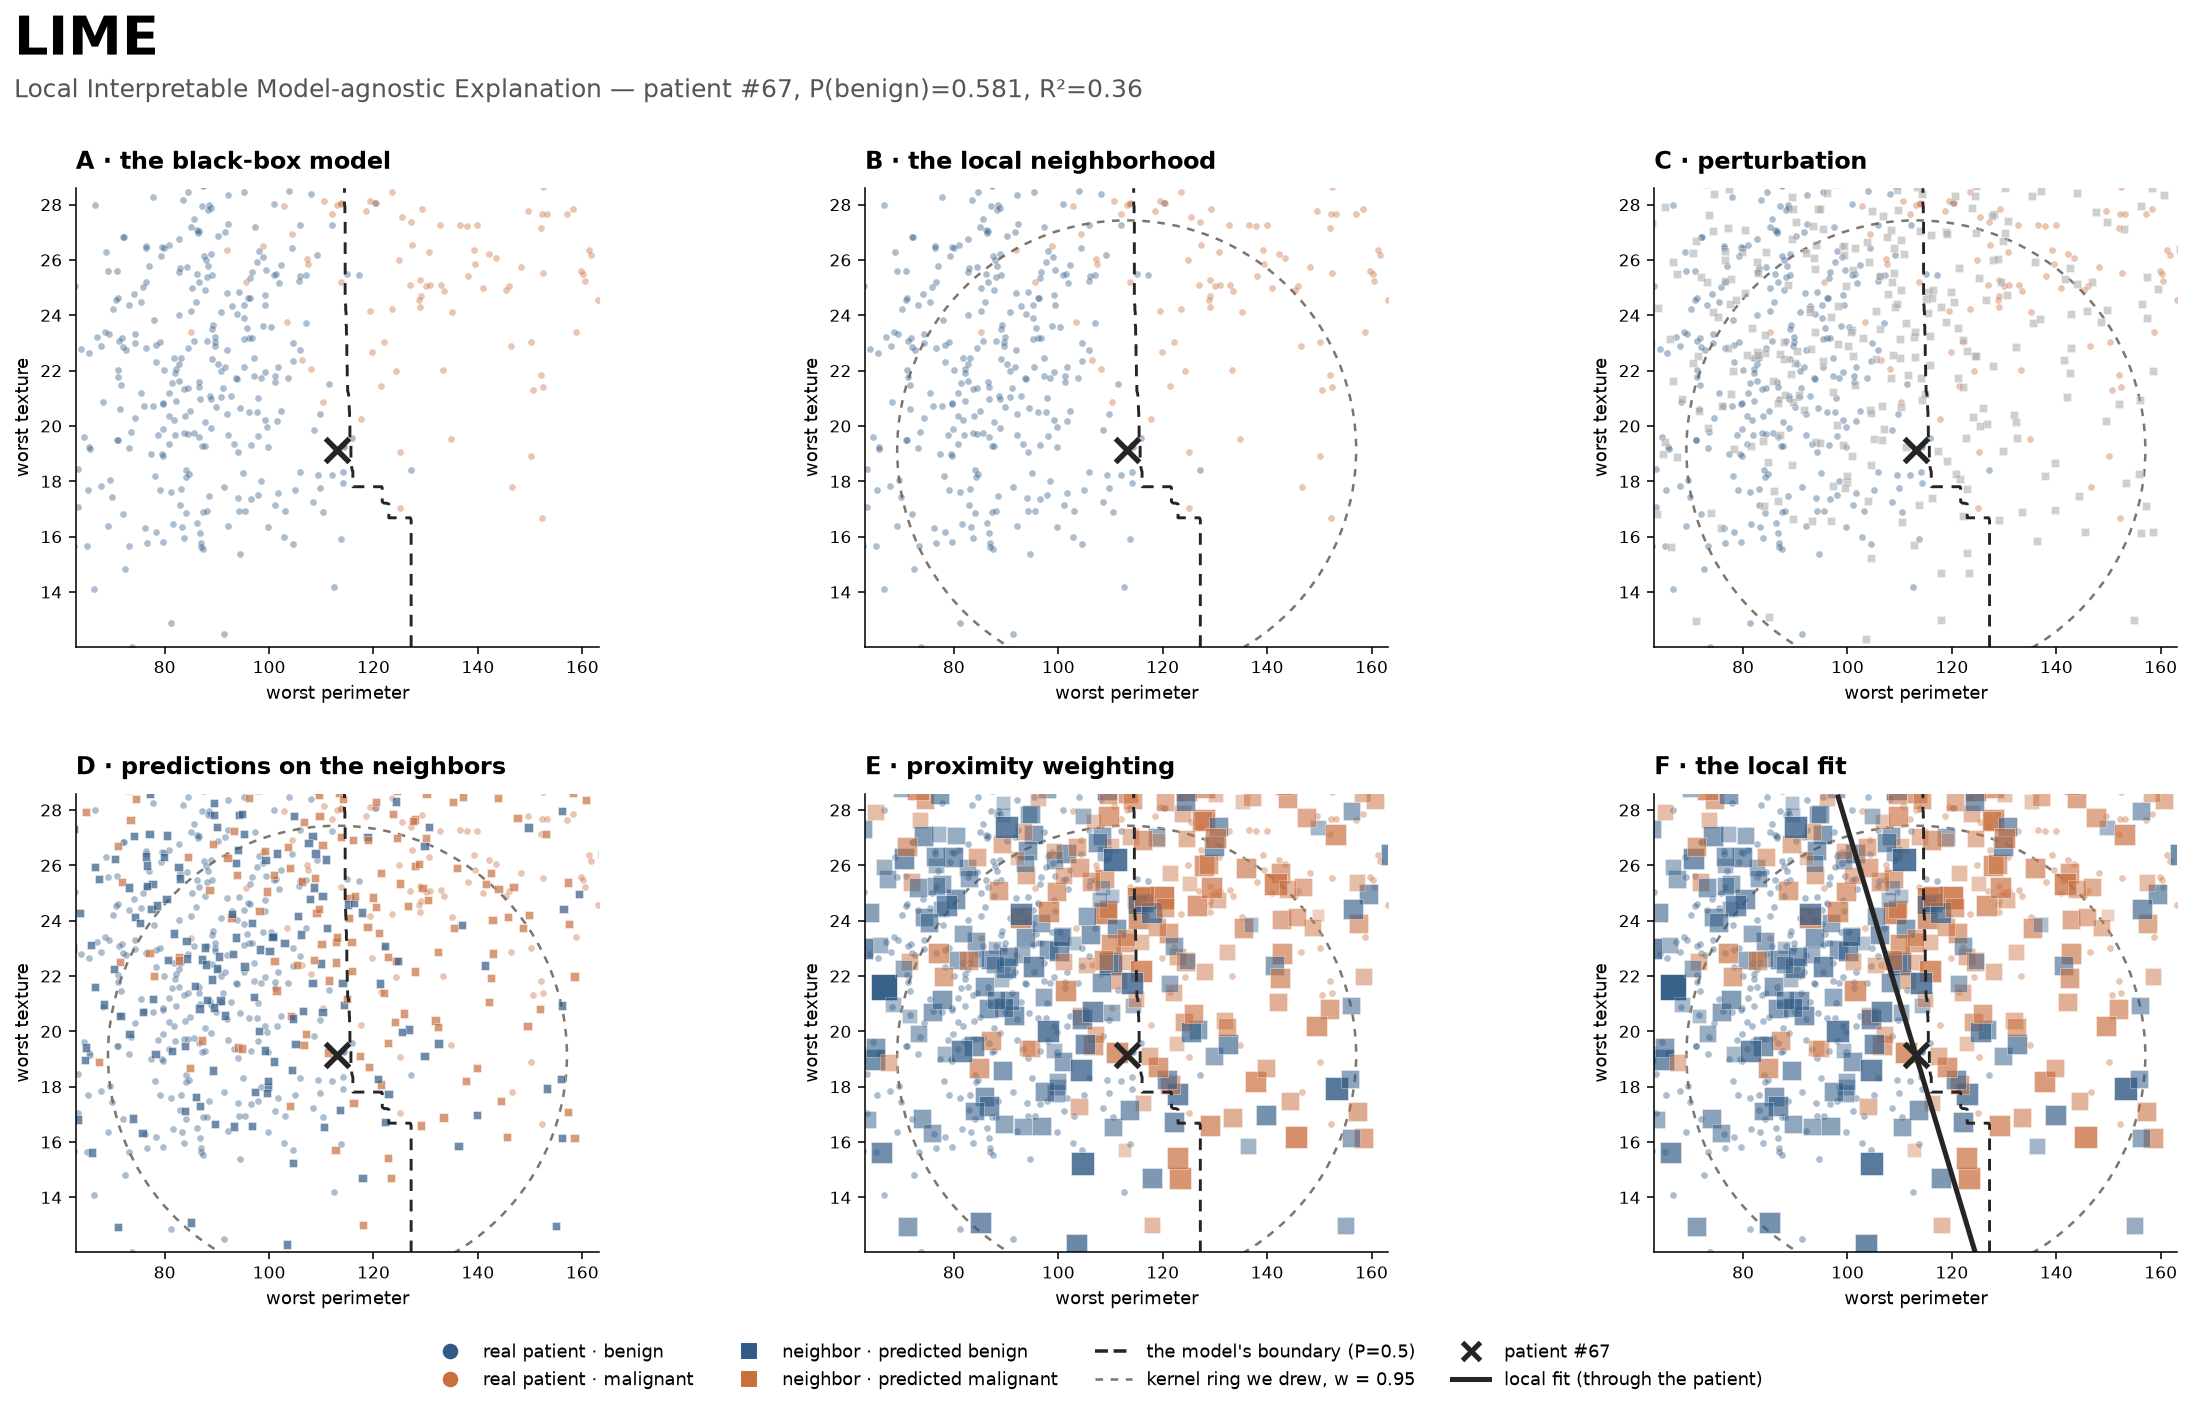

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.subplots_adjust(left=0.045, right=0.98, top=0.86, bottom=0.10, wspace=0.22, hspace=0.32)

panel_titles = [
    "A · the black-box model", "B · the local neighborhood", "C · perturbation",
    "D · predictions on the neighbors", "E · proximity weighting", "F · the local fit",
]
axA, axB, axC, axD, axE, axF = axes.ravel()

# Lock the data rectangle so the kernel ring draws as the circle it is. The
# weight depends only on Euclidean distance in standardized space, so its
# contour is a sphere; both axes are in sigma but do not span the same number
# of them (the texture window is clipped by that feature's observed range), so
# the rectangle carries the difference. Without this the ring comes out
# visibly wider than tall on the two panels that are about distance.
BOX = (((grid_y.max() - grid_y.min()) / train_std[iy])
       / ((grid_x.max() - grid_x.min()) / train_std[ix]))
# Three jobs, three treatments: dark long dash is the model's own boundary,
# muted medium dash is a kernel contour we drew. They used to be identical.
L_BOUNDARY = dict(color=DARK, linestyle=(0, (4, 3)), linewidth=1.5)
L_KERNEL = dict(color="#6D675F", linestyle=(0, (3, 3)), linewidth=1.3)

for ax, title in zip(axes.ravel(), panel_titles):
    ax.set_box_aspect(BOX)
    ax.set_title(title, loc="left", fontsize=12.5, fontweight="bold", pad=10)
    ax.set_xlim(grid_x.min(), grid_x.max())
    ax.set_ylim(grid_y.min(), grid_y.max())
    ax.set_xlabel(axis_x_name, fontsize=9.5)
    ax.set_ylabel(axis_y_name, fontsize=9.5)
    ax.tick_params(labelsize=8.5)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.scatter(X_all[y_all == 1, ix], X_all[y_all == 1, iy], s=12, color=BLUE, alpha=0.4, linewidth=0)
    ax.scatter(X_all[y_all == 0, ix], X_all[y_all == 0, iy], s=12, color=TERRACOTTA, alpha=0.4, linewidth=0)
    ax.contour(GX, GY, PROB_SLICE, levels=[0.5], colors=[L_BOUNDARY["color"]],
               linewidths=L_BOUNDARY["linewidth"], linestyles=[L_BOUNDARY["linestyle"]])

for ax in (axB, axC, axD, axE, axF):
    ax.add_patch(Ellipse((row[ix], row[iy]),
                         width=2 * R95 * train_std[ix], height=2 * R95 * train_std[iy],
                         fill=False, alpha=0.9, **L_KERNEL))

axC.scatter(Z_vis[:, ix], Z_vis[:, iy], s=16, marker="s", color=GRAY, alpha=0.55,
            linewidth=0.3, edgecolors="white")
axD.scatter(Z_vis[:, ix], Z_vis[:, iy], s=18, marker="s", color=neighbor_colors, alpha=0.7,
            linewidth=0.3, edgecolors="white")
for ax in (axE, axF):
    ax.scatter(Z_vis[:, ix], Z_vis[:, iy], s=neighbor_sizes * 0.7, marker="s",
               color=neighbor_colors, alpha=neighbor_alphas, linewidth=0.3, edgecolors="white")

if fit_drawn:
    y_line, inside = local_isoline(exp, row, grid_x, grid_y)
    axF.plot(grid_x[inside], y_line[inside], color=DARK, linewidth=2.6)

for ax in (axA, axB, axC, axD, axE, axF):
    ax.scatter(row[ix], row[iy], s=150, marker="x", color=DARK, linewidths=2.8, zorder=20)

handles = [
    plt.Line2D([], [], marker="o", linestyle="", color=BLUE, markersize=7, label="real patient · benign"),
    plt.Line2D([], [], marker="o", linestyle="", color=TERRACOTTA, markersize=7, label="real patient · malignant"),
    plt.Line2D([], [], marker="s", linestyle="", color=BLUE, markersize=7, label="neighbor · predicted benign"),
    plt.Line2D([], [], marker="s", linestyle="", color=TERRACOTTA, markersize=7, label="neighbor · predicted malignant"),
    plt.Line2D([], [], color=DARK, linewidth=1.8, linestyle="--", label="the model's boundary (P=0.5)"),
    plt.Line2D([], [], color="#6D675F", linewidth=1.3, linestyle=(0, (3, 3)), alpha=0.9, label="kernel ring we drew, w = 0.95"),
    plt.Line2D([], [], marker="x", linestyle="", color=DARK, markersize=9, markeredgewidth=2.6,
               label=f"patient #{instance_idx}"),
    plt.Line2D([], [], color=DARK, linewidth=2.6, label="local fit (through the patient)"),
]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=9.5, frameon=False,
           bbox_to_anchor=(0.5, -0.01))

fig.suptitle("LIME", fontsize=28, fontweight="bold", x=0.045, ha="left", y=0.985)
fig.text(0.045, 0.925,
         f"Local Interpretable Model-agnostic Explanation — patient #{instance_idx}, "
         f"P(benign)={row_proba:.3f}, R²={r2:.2f}",
         fontsize=13, color="#555555", ha="left")

save_figure(fig, "lime_walkthrough_combined")
fig.savefig(os.path.join(FIG_DIR, "lime_walkthrough_combined.pdf"), bbox_inches="tight")
plt.show()


## Closing — where explanations are needed most

The single test split used above is too small to characterise the model's
weak spot: only six of its 143 patients are borderline. Ten-fold
cross-validation over all 569 patients gives a usable sample.

In [21]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
p_cv = cross_val_predict(
    RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE),
    X_all, y_all, cv=cv, method="predict_proba")[:, 1]
pred_cv = (p_cv >= 0.5).astype(int)
conf_cv = np.abs(p_cv - 0.5)
print(f"10-fold CV over all {len(y_all)} patients: accuracy {accuracy_score(y_all, pred_cv):.1%}, "
      f"ROC-AUC {roc_auc_score(y_all, p_cv):.3f}")
for lo, hi, lab in [(0.30, 0.51, "confident  (|P-0.5| > 0.30)"),
                    (0.00, 0.15, "borderline (|P-0.5| < 0.15)")]:
    s = (conf_cv >= lo) & (conf_cv < hi)
    print(f"  {lab:30s} n={s.sum():3d} ({s.mean():.0%})   accuracy {accuracy_score(y_all[s], pred_cv[s]):.1%}")

10-fold CV over all 569 patients: accuracy 95.3%, ROC-AUC 0.989
  confident  (|P-0.5| > 0.30)    n=492 (86%)   accuracy 99.4%
  borderline (|P-0.5| < 0.15)    n= 34 (6%)   accuracy 52.9%


Where the model is confident it is essentially never wrong. Where it
hesitates — one patient in sixteen — it is barely better than a coin
flip. Those are the cases a clinician would actually bring to a second
opinion, and they are exactly the cases this lecture has been about.

What LIME gave us for one of them: a direction that matches the model's
real local behavior to within a few degrees in the plane we could draw, a
ranked list of which measurements pushed the verdict, and — once we
measured rather than assumed — a clear account of which parts of that
picture to trust. The level was biased, the 30-D coefficient ranking only
moderately reliable, and the neighborhood it reasoned over was made of
patients who could not exist.

LIME's value is not that it is never wrong. It is that, once you measure
it, you can say precisely how it is wrong — and that is the difference
between an explanation and a reassurance.